# Student Performance Prediction in Bangladesh
This notebook demonstrates a complete machine learning pipeline to predict HSC results based on student demographics, family background, and previous academic performance (SSC results).

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading and Initial Exploration
In this section, we load the dataset and perform a quick check of the data structure, including shapes, samples, and summary statistics to understand the features we are working with.

In [19]:
df = pd.read_csv("bangladesh_student_performance_updated.csv")

In [20]:
df

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
0,29/04/2018,M,18.0,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672.0,4,4.22,3.72
1,29/04/2018,F,19.0,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085.0,5,3.47,2.62
2,29/04/2018,F,19.0,Rural,GT3,Together,0,3,Teacher,Services,No,No,40891.0,3,3.32,2.56
3,29/04/2018,F,19.0,Rural,LE3,Apart,2,3,At_home,Business,No,No,50600.0,2,4.57,4.17
4,29/04/2018,M,17.0,Rural,GT3,Together,1,1,At_home,Farmer,No,No,62458.0,2,4.50,3.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013,29/04/2018,M,18.0,Urban,GT3,Together,2,2,Teacher,Health,No,No,108426.0,2,3.57,3.18
2014,29/04/2018,M,19.0,Urban,GT3,Together,0,3,Other,Teacher,Yes,No,100665.0,5,4.05,3.13
2015,29/04/2018,M,18.0,Urban,GT3,Together,3,2,Services,Farmer,Yes,No,92291.0,1,3.93,3.15
2016,29/04/2018,M,19.0,Rural,GT3,Together,0,2,At_home,Teacher,No,No,43926.0,3,3.34,2.83


In [21]:
df.shape

#data = 2018
#feature = 16

(2018, 16)

In [22]:
df.sample(10)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
1137,29/04/2018,M,19.0,Rural,LE3,Together,2,2,Health,Teacher,No,No,54464.0,5,3.68,2.77
570,29/04/2018,M,18.0,Urban,LE3,Together,0,4,At_home,Health,No,No,66236.0,5,3.28,2.58
21,29/04/2018,M,17.0,Urban,GT3,Together,1,1,Other,Services,No,No,85900.0,3,3.69,3.04
142,29/04/2018,M,17.0,Urban,GT3,Together,3,3,Teacher,Teacher,No,No,105402.0,5,3.78,3.29
314,29/04/2018,F,18.0,Rural,GT3,Together,0,2,At_home,Health,No,No,35561.0,3,4.11,3.30
1700,29/04/2018,F,18.0,Urban,LE3,Together,2,2,At_home,Health,No,No,105892.0,1,4.30,3.78
1672,29/04/2018,F,18.0,Rural,GT3,Together,4,2,Services,Business,No,No,62696.0,2,3.69,3.17
978,29/04/2018,M,19.0,Rural,GT3,Apart,2,4,At_home,Farmer,Yes,No,60215.0,2,4.43,3.50
1211,29/04/2018,M,19.0,Rural,GT3,Together,0,2,Health,Teacher,Yes,Yes,69514.0,2,4.16,3.18
1346,29/04/2018,M,19.0,Rural,GT3,Together,1,1,Services,Teacher,No,No,35690.0,5,3.52,2.97


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           1983 non-null   float64
 3   address       1983 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         1983 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   1983 non-null   float64
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(4), int64(3), object(9)
memory usage: 252.4+ KB


In [24]:
df['time_friends'].unique()
df['M_Edu'].unique()

# categorical values can be integer 

array([3, 0, 2, 1, 4])

In [25]:
df.isnull().sum()

date             0
gender           0
age             35
address         35
famsize          0
Pstatus          0
M_Edu            0
F_Edu            0
M_Job           35
F_Job            0
relationship     0
smoker           0
tuition_fee     35
time_friends     0
ssc_result       0
hsc_result       0
dtype: int64

In [26]:
df.describe()

,age,M_Edu,F_Edu,tuition_fee,time_friends,ssc_result,hsc_result
count,1983.000000,2018.000000,2018.000000,1983.000000,2018.00000,2018.000000,2018.000000
mean,17.980837,1.871160,2.174430,73045.274332,3.05996,3.788087,3.199177
std,0.825695,1.194206,1.252979,24102.016020,1.43919,0.622376,0.604526
min,17.000000,0.000000,0.000000,25102.000000,1.00000,2.000000,2.000000
25%,17.000000,1.000000,1.000000,53639.500000,2.00000,3.360000,2.780000
50%,18.000000,2.000000,2.000000,71343.000000,3.00000,3.770000,3.160000
75%,19.000000,3.000000,3.000000,91185.000000,4.00000,4.230000,3.580000
max,19.000000,4.000000,4.000000,129168.000000,5.00000,5.000000,5.000000


In [29]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

## 2. Exploratory Data Analysis (EDA)
Visualizing the data helps us identify patterns, correlations between features, and potential outliers. We look at the distribution of numerical features and the relationship between our target variable (hsc_result) and other predictors.

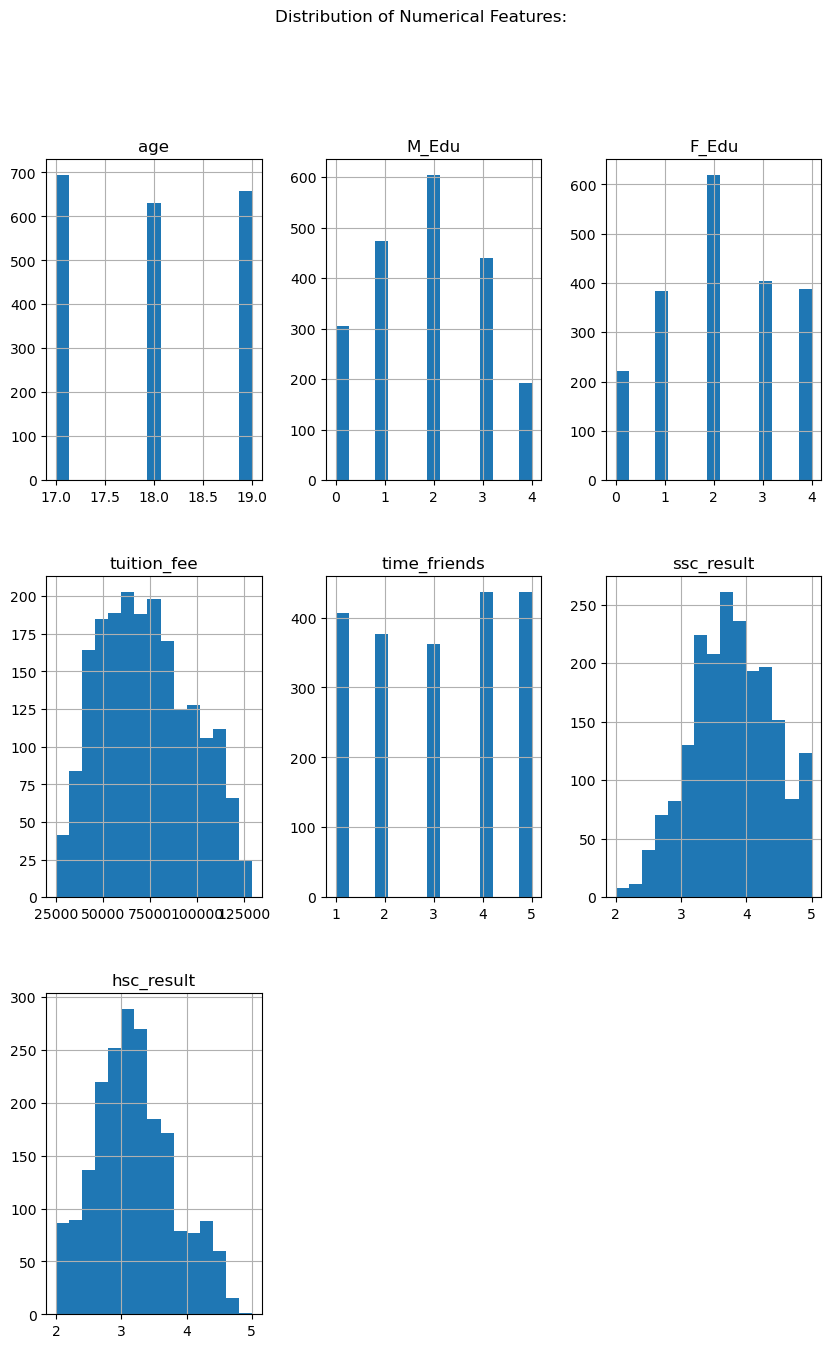

In [37]:
df.hist(bins=15, figsize=(10, 15))

plt.suptitle("Distribution of Numerical Features:",)
plt.show()

In [ ]:
# corelation heatmap
numerical_cols= ['age','tuition_fee', "ssc_result", "hsc_result"]

df[numerical_cols].corr()

# not appropriate for research paper

,age,tuition_fee,ssc_result,hsc_result
age,1.000000,0.001015,-0.013061,-0.012592
tuition_fee,0.001015,1.000000,0.018385,0.041205
ssc_result,-0.013061,0.018385,1.000000,0.950178
hsc_result,-0.012592,0.041205,0.950178,1.000000


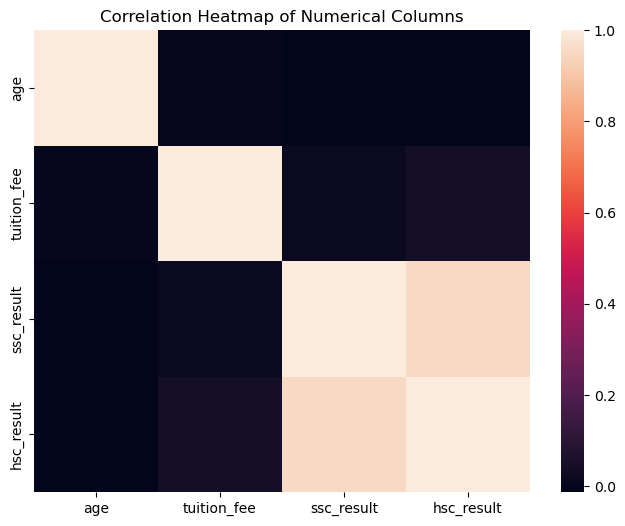

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[numerical_cols].corr()
    
)
plt.title("Correlation Heatmap of Numerical Columns")
plt.show()
#issues: what is happening here? unclear to understand

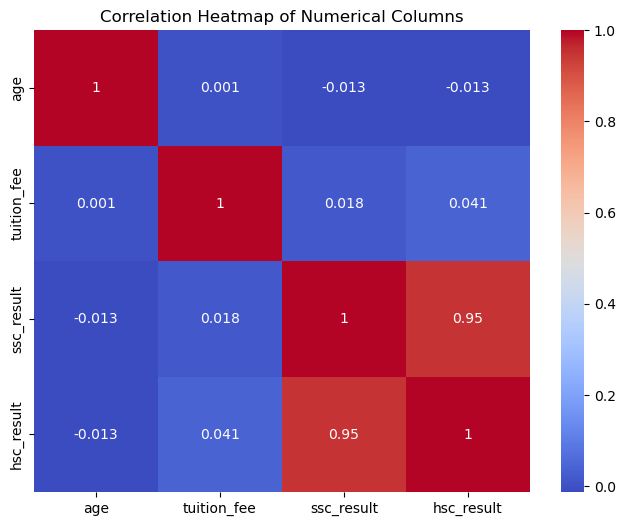

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[numerical_cols].corr(),
    annot= True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap of Numerical Columns")
plt.show()
# More visually readable
# Red= directly correlated
# Blue= less coorelated

<Axes: xlabel='age'>

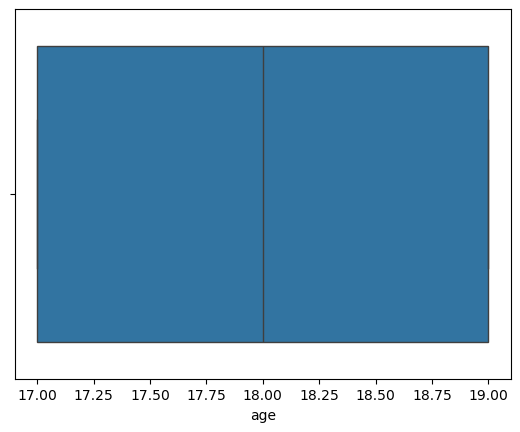

In [44]:
sns.boxplot(data=df, x="age")

<Axes: xlabel='ssc_result'>

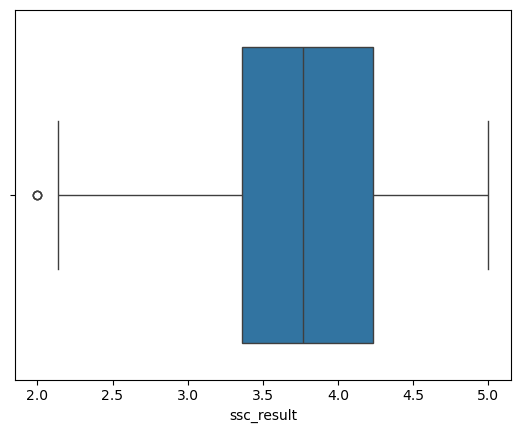

In [ ]:
sns.boxplot(data=df, x="ssc_result") # there are outliers

## preprocessing
Preprocessing is a critical step where we handle missing values, encode categorical variables (nominal and ordinal), and scale numerical features to prepare them for the machine learning models.

## 3. Model Training
We evaluate two different linear regression models to see which one performs better on this specific dataset:
1. **Linear Regression**: A standard approach for regression tasks.
2. **SGD Regressor**: Uses Stochastic Gradient Descent, which is efficient for larger datasets.

# Linear Regression

# Accuracy of the models

## 4. Final Evaluation
We compare the performance of the models using metrics like Mean Squared Error (MSE), R-squared (R2), and Mean Absolute Error (MAE). These metrics tell us how close our predictions are to the actual student results.